# Sign Language
Data Analysis - ISAE 2025/2026

In [48]:
if "google.colab" in str(get_ipython()):
    !curl -O https://raw.githubusercontent.com/PetitMalo/BE_data_analysis/main/bootstrap.py && python3 bootstrap.py

In [49]:
import json
import os
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import skimage
import xgboost as xgb
from scipy import ndimage
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

from src.hyper_param_search import find_mlp_hyperparams, find_xgb_hyperparams_gpu
from src.utils import display_classification_metrics, get_latest_hyperparams, logger

%matplotlib inline

SEED = 42

Loading the dataset

In [50]:
data_path = "./data"
X_file = os.path.join(data_path, "X.npy")  # X
y_file = os.path.join(data_path, "y.npy")  # y

## 1 - Data import and formatting


In [51]:
# Load input data and labels
X = np.load(X_file)
y = np.load(y_file)
print("Shapes of input data:")
print(X.shape)
print("Shapes of labels:")
print(y.shape)

Shapes of input data:
(2062, 64, 64)
Shapes of labels:
(2062, 10)


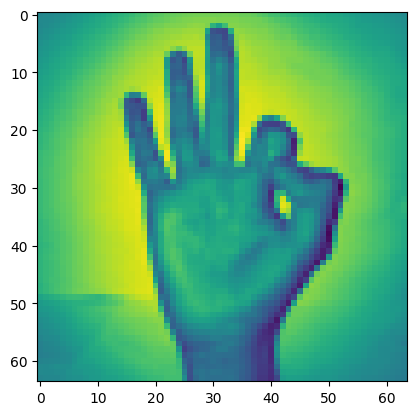

Label of image is:
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [52]:
# Display an image and its label
img_idx = 55
plt.imshow(X[img_idx])
plt.show()
print("Label of image is:")
print(y[img_idx])

In [53]:
# Let's define a function that converts the one-hot encoded labels to the corresponding sign
# language value.
def label_to_sign_number(label: int) -> int:
    """
    Convert a one-hot encoded label to the
    corresponding sign language value.
    Mapping it with the truth value.

    Args:
      label: (numpy.array) One-hot encoded label

    Returns: (float) Sign language value
    """
    label_value = np.argmax(label)
    mapping = {0: 9, 1: 0, 2: 7, 3: 6, 4: 1, 5: 8, 6: 4, 7: 3, 8: 2, 9: 5}
    return mapping[label_value]

Image 55 is a: 9


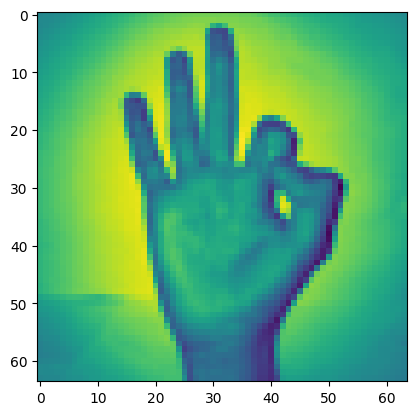

In [54]:
# Let's test our function
y55 = label_to_sign_number(y[img_idx])
print("Image 55 is a: {}".format(y55))
plt.imshow(X[img_idx])
plt.show()

### Data visualization

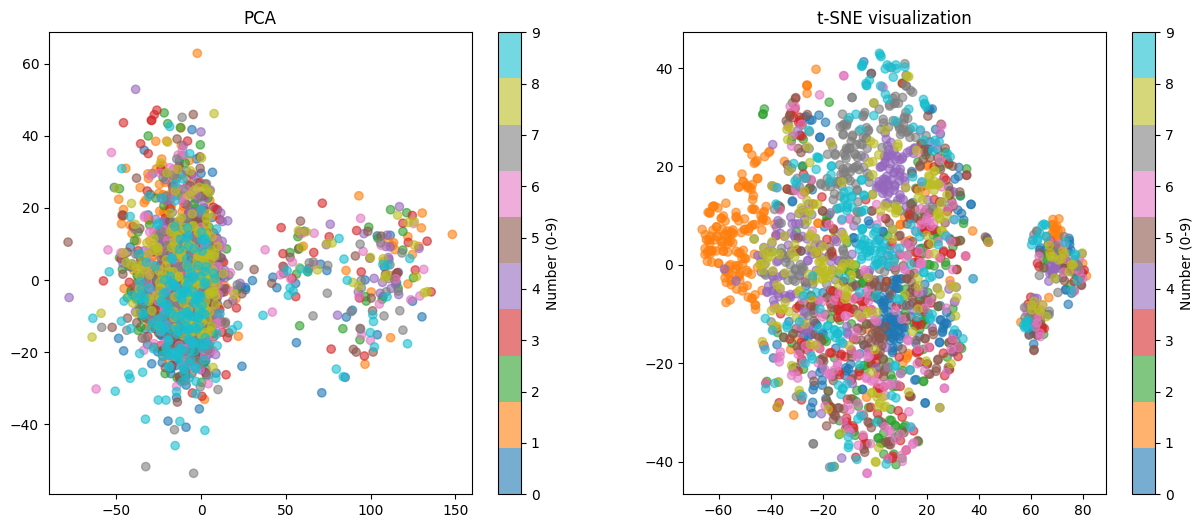

In [55]:
X_flat = X.reshape(X.shape[0], -1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=np.argmax(y, axis=1), cmap='tab10', alpha=0.6)
plt.title("PCA")
plt.colorbar(label='Number (0-9)')
plt.subplot(1, 2, 2)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=np.argmax(y, axis=1), cmap='tab10', alpha=0.6)
plt.title("t-SNE visualization")
plt.colorbar(label='Number (0-9)')
plt.show()

## 2 - Features construction with filters

In [56]:
# Let's apply some edge detectors on an example image
img_idx = 900  # select an image index
img = X[img_idx]  # get the grayscale image matrix

# Sobel operator
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
gx = ndimage.convolve(img, sobel_x)
gy = ndimage.convolve(img, sobel_y)
edges_sobel = np.sqrt(gx**2 + gy**2)

# Laplacian operator
laplacian = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
edges_laplacien = ndimage.convolve(img, laplacian)

# Personal operator (sobel + max pooling 2D)
processed_img = ndimage.convolve(img, sobel_x)
processed_img = skimage.measure.block_reduce(processed_img, (2, 2), np.max)

# processed_img2 = ndimage.convolve(img, sobel_x)
# processed_img2 = skimage.measure.block_reduce(processed_img2, (2, 2), np.max)

other_processed_img = ndimage.convolve(img, laplacian)
other_processed_img = skimage.measure.block_reduce(other_processed_img, (2, 2), np.max)

# other_processed_img2 = ndimage.convolve(img, laplacian)
# other_processed_img2 = skimage.measure.block_reduce(other_processed_img2, (2, 2), np.max)

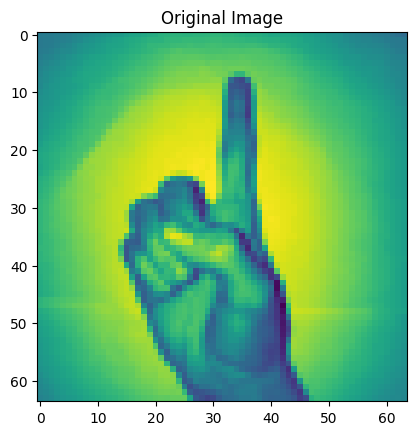

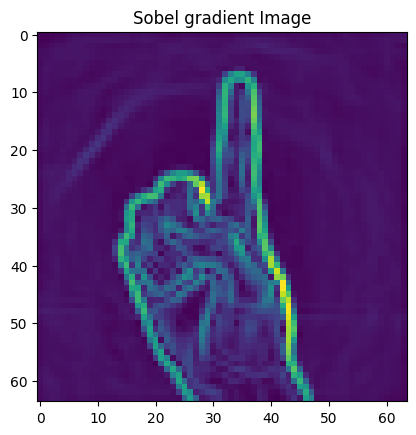

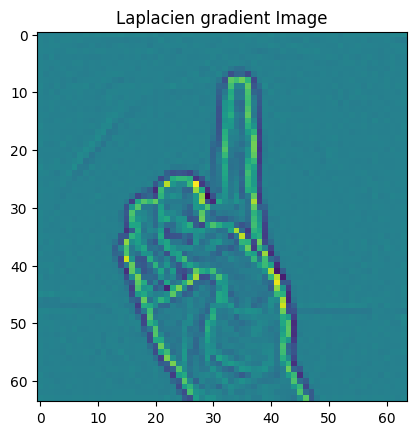

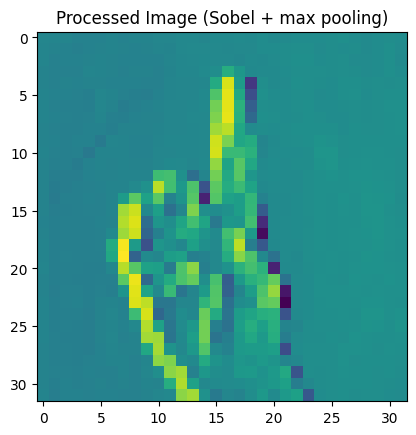

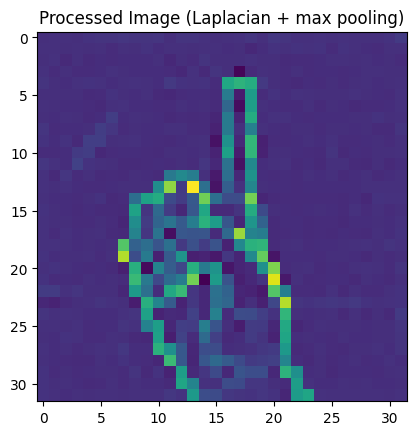

In [57]:
# Let's display the image
def displayImg(_img, title=""):
    plt.imshow(_img)
    plt.title(title)
    plt.show()


displayImg(img, "Original Image")
displayImg(edges_sobel, "Sobel gradient Image")
displayImg(edges_laplacien, "Laplacien gradient Image")
displayImg(processed_img, "Processed Image (Sobel + max pooling)")
displayImg(other_processed_img, "Processed Image (Laplacian + max pooling)")
# displayImg(processed_img2, "Processed Image (max pooling + sobel)")
# displayImg(other_processed_img2, "Processed Image (max pooling + laplacian)")

# print((other_processed_img2 - other_processed_img == 0).all())

In [58]:
def preprocessing(
    X: np.ndarray, y: np.ndarray, scaler_dir: str = "./models/scaler"
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Preprocess the input data by applying sobel filter and maxpooling.

    Args:
        X: (numpy.array) Input data of shape (num_samples, height, width)
        y: (numpy.array) Labels of shape (num_samples, num_classes)
        scaler_dir: (str) Directory to save the scaler parameters
    Returns:
        X_train, X_val, X_test, y_train, y_val, y_test: (tuple) Preprocessed data and labels
    """
    logger.info("Preprocessing dataset")
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    X_processed = []
    for img in tqdm(X, desc="Preprocessing images", total=len(X)):
        gx = ndimage.convolve(img, sobel_x)
        gy = ndimage.convolve(img, sobel_y)
        edges_sobel = np.sqrt(gx**2 + gy**2)
        processed_img = skimage.measure.block_reduce(edges_sobel, (2, 2), np.max)
        X_processed.append(processed_img)

    # Train, test, split
    logger.info("Splitting dataset into train, validation and test sets")
    X_processed = np.array(X_processed)
    X_flat = X_processed.reshape((X_processed.shape[0], -1))  # flatten the images
    y_flat = np.array([label_to_sign_number(label) for label in y])
    X_train, X_test, y_train, y_test = train_test_split(
        X_flat, y_flat, test_size=0.25, random_state=SEED, stratify=y_flat
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.25, random_state=SEED, stratify=y_train
    )

    logger.info("Scaling dataset")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    X_val = scaler.transform(X_val)

    os.makedirs(scaler_dir, exist_ok=True)
    logger.info(f"Saving scaler to: {scaler_dir}")
    with open(
        os.path.join(scaler_dir, f"scaler_params_{datetime.now().strftime('%Y%m%dT%H%M%S')}.json"),
        "w",
    ) as f:
        json.dump(
            {
                "mean": scaler.mean_.tolist(),
                "scale": scaler.scale_.tolist(),
            },
            f,
        )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [59]:
X_train, X_val, X_test, y_train, y_val, y_test = preprocessing(X, y)

2026-02-18 17:43:53.473 | INFO     | __main__:preprocessing:14 - Preprocessing dataset
Preprocessing images: 100%|██████████| 2062/2062 [00:00<00:00, 2674.19it/s]
2026-02-18 17:43:54.253 | INFO     | __main__:preprocessing:26 - Splitting dataset into train, validation and test sets
2026-02-18 17:43:54.272 | INFO     | __main__:preprocessing:37 - Scaling dataset
2026-02-18 17:43:54.289 | INFO     | __main__:preprocessing:44 - Saving scaler to: ./models/scaler


## 3 - Classification with models

### 3.1 - Ensembling models

#### 3.1.1 - XGBClassifier

In [60]:
search_xgb_best_params = False
if search_xgb_best_params:
    logger.info("Searching for optimal hyperparameters...")
    hyper_params = find_xgb_hyperparams_gpu(X_train, y_train, X_val, y_val)
    logger.info(f"Optimal hyperparameters found: {hyper_params}")

In [61]:
try:
    logger.info("Best hyperparameters:")
    logger.info(hyper_params)
except NameError:
    hyper_param_path = "./models/xgb_best_hyperparams.json"
    hyper_params = get_latest_hyperparams(prefix="xgb_best_hyperparams")
    logger.info(f"Using previously found hyperparameters from: {hyper_param_path}")
    logger.info(hyper_params)

xgb_clf = xgb.XGBClassifier(**hyper_params, random_state=SEED).fit(X_train, y_train)
score = xgb_clf.score(X_test, y_test)
logger.info(f"Test set accuracy: {score}")

2026-02-18 17:43:54.327 | INFO     | __main__:<module>:2 - Best hyperparameters:
2026-02-18 17:43:54.328 | INFO     | __main__:<module>:3 - {'hidden_layer_sizes': [67, 74, 70, 57]}
/home/mdacher/private/supaero/OT/BE_data_analysis/DATA ANALYSIS/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [17:43:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "hidden_layer_sizes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026-02-18 17:44:26.750 | INFO     | __main__:<module>:12 - Test set accuracy: 0.7829457364341085


2026-02-18 17:44:26.805 | INFO     | src.utils:display_classification_metrics:21 - Classification Report:



               precision    recall  f1-score   support

           0       0.88      0.84      0.86        51
           1       0.83      0.87      0.85        52
           2       0.69      0.67      0.68        51
           3       0.87      0.90      0.89        52
           4       0.67      0.65      0.66        52
           5       0.92      0.85      0.88        52
           6       0.65      0.60      0.62        52
           7       0.69      0.69      0.69        51
           8       0.81      0.85      0.83        52
           9       0.81      0.92      0.86        51

    accuracy                           0.78       516
   macro avg       0.78      0.78      0.78       516
weighted avg       0.78      0.78      0.78       516



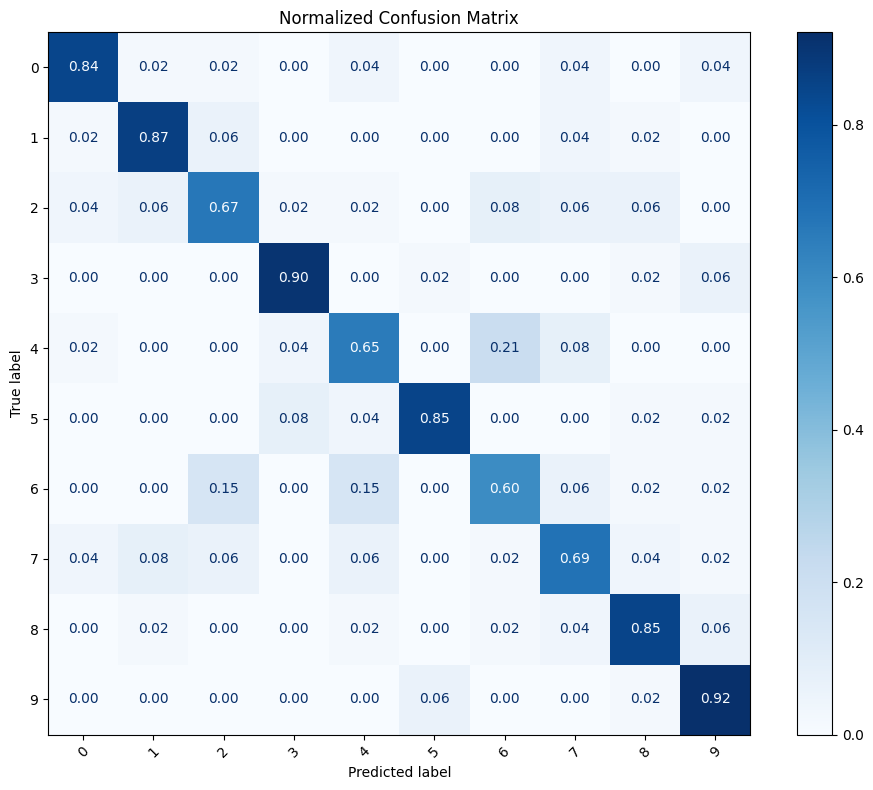

In [62]:
y_pred = xgb_clf.predict(X_test)
display_classification_metrics(y_test, y_pred)

### 3.2 - MLPClassifier

In [63]:
search_mlp_best_params = False
if search_mlp_best_params:
    logger.info("Searching for optimal hyperparameters...")
    hyper_params = find_mlp_hyperparams(X_train, y_train, X_val, y_val)
    logger.info(f"Optimal hyperparameters found: {hyper_params}")

In [64]:
hyper_param_path = "./models/mlp_best_hyperparams.json"
hyper_params = get_latest_hyperparams(prefix="mlp_best_hyperparams")
logger.info(f"Using previously found hyperparameters from: {hyper_param_path}")
logger.info(hyper_params)

mlp_clf = MLPClassifier(**hyper_params, random_state=SEED).fit(X_train, y_train)
score = mlp_clf.score(X_test, y_test)
logger.info(f"Test set accuracy: {score}")

2026-02-18 17:44:27.216 | INFO     | src.utils:get_latest_hyperparams:54 - Loading latest hyperparameters from: %s
2026-02-18 17:44:27.217 | INFO     | __main__:<module>:3 - Using previously found hyperparameters from: ./models/mlp_best_hyperparams.json
2026-02-18 17:44:27.219 | INFO     | __main__:<module>:4 - {'hidden_layer_sizes': [67, 74, 70, 57]}
2026-02-18 17:44:28.656 | INFO     | __main__:<module>:8 - Test set accuracy: 0.7732558139534884


2026-02-18 17:54:41.542 | INFO     | src.utils:display_classification_metrics:21 - Classification Report:



               precision    recall  f1-score   support

           0       0.76      0.75      0.75        51
           1       0.90      0.90      0.90        52
           2       0.70      0.76      0.73        51
           3       0.90      0.88      0.89        52
           4       0.66      0.71      0.69        52
           5       0.85      0.87      0.86        52
           6       0.76      0.67      0.71        52
           7       0.65      0.65      0.65        51
           8       0.90      0.71      0.80        52
           9       0.70      0.82      0.76        51

    accuracy                           0.77       516
   macro avg       0.78      0.77      0.77       516
weighted avg       0.78      0.77      0.77       516



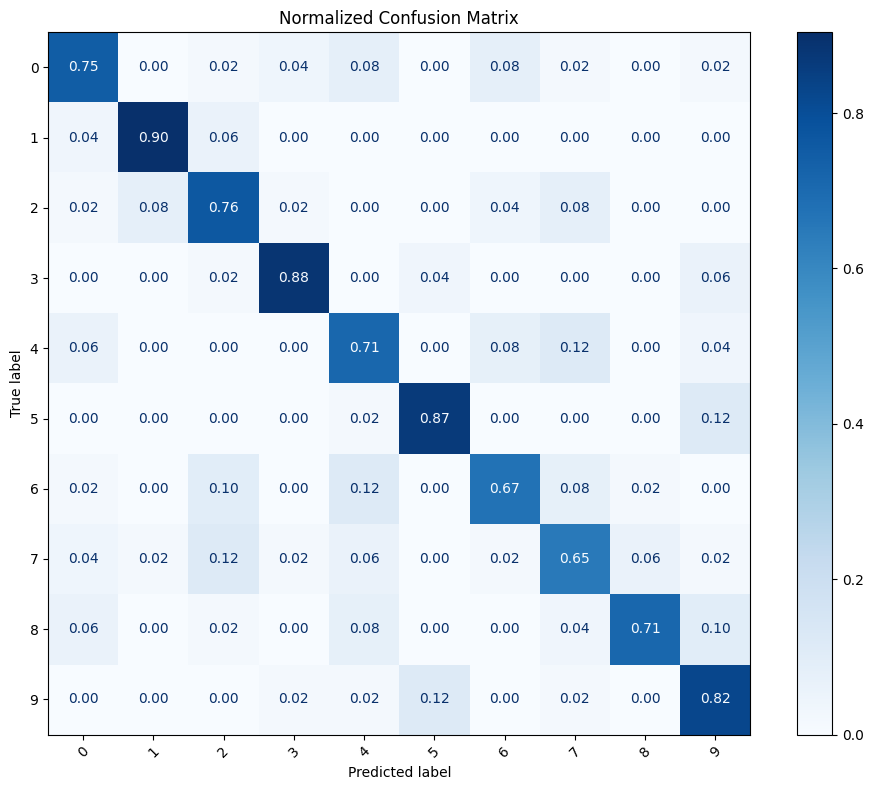

In [66]:
y_pred = mlp_clf.predict(X_test)
display_classification_metrics(y_test, y_pred)